# FIP 11 — Large DA and NE transients: shared, solo, and the movement around them

How often does a large transient in one signal come with one in the other, how are the matched
pairs timed and sized, and how much movement surrounds shared and solo transients?

1. **Shared and solo transients** (97 sessions): rate, solo fraction against chance, coupling, by
   size and task context, and both traces around each group.
2. **Detection threshold**: the solo fraction at other prominence thresholds.
3. **Matched pairs**: the lag between partners and the correlation of their sizes, by context.
4. **Movement around large transients** (88 sessions with a usable bottom camera): ME around shared
   and solo transients, its window mean and its peak.
5. Numbers

**Signals.** DA: dLight in lateral NAc (`latNAcc(X)-DA`). NE: GCaMP in LC noradrenergic axons
imaged in PL (`PL(X)-LCAxonCa`), i.e. axonal calcium. Both are `dff-bright_mc-iso-IRLS` dF/F at
20 Hz. The two indicators have different kinetics, so lags describe the recorded signals, not
timing in the brain.

**Movement** is motion energy (ME) from the bottom camera: the summed absolute frame-to-frame pixel
change, from the aligned ME table (`fip_motion_energy_aligned`, frame times corrected by the video
timing QC). Cameras that fail the video timing or quality screen are left out (`men_01`).

**Data.** The CSV-curated `DANE_3channels_curated` and `DANE_4channels_curated` assets. Each animal
contributes one hemisphere (the side with more sessions), with DA and NE from that side; animals
need at least 3 sessions (`fu.inventory_pairs`, `fu.choose_side`, `fu.load_pairs`). Traces sit on
one 20 Hz grid from 5 s before the first go cue to 10 s after the last; ME is averaged into the same
bins (`fu.add_motion_energy`). Each trace is z-scored over the session.

**Statistics.** Session values are averaged within animal; tests are Wilcoxon signed-rank on animal
means (smallest two-sided p with 9 animals: 0.004). Error bands are SEM over animals.

**Conventions.** + lag = NE later. Colors: DA vermillion, NE blue, ME dark grey.

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats

import fip_utils as fu
import signal_utils as su
import stats_utils as st
import behavior_utils as bu
import plot_utils as pu
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
ME_DATA_ROOT = "/root/capsule/data" if IS_CO else os.environ.get("ME_DATA_ROOT", "../../data")
PAIRS_CACHE = ("/root/capsule/scratch/fip_05/pairs.pkl" if IS_CO
               else "../../data/fip_05_cache/pairs.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

# ── Data ─────────────────────────────────────────────────────────────────────
FS = 20.0                  # Hz, the common grid
CAMERA = "BottomCamera"
MIN_SESSIONS_PER_ANIMAL = 3
EXCLUDE_SUBJECTS = ()      # QC decides; none excluded

# ── Transients ───────────────────────────────────────────────────────────────
LARGE_PROM = 2.0             # z prominence of a "large" transient
PARTNER_PROM = 1.0           # z prominence that counts as a partner in the other signal
MATCH_WIN_S = 0.5            # partner must peak within this many s
MIN_SEP_S = 0.5              # minimum spacing of peaks in one signal
PROM_BINS = [2.0, 2.5, 3.0, 4.0, np.inf]
PROM_SWEEP = [1.5, 2.0, 2.5, 3.0]   # section 2
CONTEXTS = ["rewarded", "unrewarded", "cue, no response", "licking", "quiet"]
LAG_BINS = np.arange(-1.55, 1.55 + 1e-9, 0.1)   # 0.1-s bins centred on the 20-Hz sample grid
ETA_LAGS = np.arange(-2.0, 3.0 + 1e-9, 1 / FS)  # around transient peaks
PEAK_WIN = (-0.5, 0.5)       # ME window around the transient peak (section 4)
EXAMPLE_SESSION = "800886_2025-09-03"   # fip_10's example session
SNIP_S = 20.0                # schematic window

# ── Colors ───────────────────────────────────────────────────────────────────
SIG = ("da", "ne", "me")
SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"], "me": "0.25"}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)", "me": "ME (bottom camera)"}
OUT_COLOR = {"rewarded": OKABE_ITO["orange"], "unrewarded": "0.55"}
NULL_COLOR = PALETTE["not_sig"]
rng = np.random.default_rng(0)

## 0. Data

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

inv = fu.inventory_pairs(asset_roots)
kept, side_table = fu.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)
pairs = fu.load_pairs(kept, fs=FS, cache_path=PAIRS_CACHE)
for p in pairs:
    p["z"] = {s: su.zscore(p[s]) for s in ("da", "ne")}
    p["t"] = p["t0"] + np.arange(len(p["da"])) / FS
me_pairs = fu.add_motion_energy(pairs, kept, CAMERA, ME_DATA_ROOT, onset_fs=None,
                                exclude_subjects=EXCLUDE_SUBJECTS)

SUBJECTS = sorted({p["subject"] for p in pairs})
N_ANIMALS = len(SUBJECTS)
PAIR_SUBJECTS = [p["subject"] for p in pairs]
ME_SUBJECTS = [p["subject"] for p in me_pairs]
N_ME_ANIMALS = len(set(ME_SUBJECTS))
print(f"{len(pairs)} sessions from {N_ANIMALS} animals; {len(me_pairs)} with bottom-camera ME "
      f"({N_ME_ANIMALS} animals)")
pd.DataFrame({"sessions": pd.Series(PAIR_SUBJECTS).value_counts(),
              "with ME": pd.Series(ME_SUBJECTS).value_counts()}).fillna(0).astype(int).T

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data


loaded 97 pairs from cache ../../data/fip_05_cache/pairs.pkl


97 sessions from 9 animals; 88 with bottom-camera ME (9 animals)


,800886,808054,809487,809491,815334,816212,816214,818585,818586
sessions,5,16,8,20,4,8,5,8,23
with ME,4,15,8,19,3,5,5,7,22


In [4]:
def per_animal(df, effect, p=None, z=None):
    """Per animal: sessions, median and range of `effect` across sessions, and per-session test summary.

    With `z` (a per-session z-score against a shift null) the median and range of z are given; the
    shift tests' p-values sit at their floor, so their range is not shown."""
    rows = []
    for subj, g in df.groupby("subject"):
        e = g[effect].dropna()
        r = dict(subject=subj, n_sessions=len(e), median=e.median(), min=e.min(), max=e.max())
        if p is not None:
            pv = g.loc[e.index, p]
            r["frac_p_lt_05"] = (pv < 0.05).mean()
            if z is None:
                r.update(p_min=pv.min(), p_max=pv.max())
        if z is not None:
            zv = g.loc[e.index, z]
            r.update(z_median=zv.median(), z_min=zv.min(), z_max=zv.max())
        rows.append(r)
    return pd.DataFrame(rows).set_index("subject")


def show_per_animal(title, df, effect, p=None, z=None, digits=3):
    """Print the per-animal table and the across-animal Wilcoxon on animal means."""
    t = per_animal(df, effect, p, z)
    m, pv, n = st.wilcoxon_animals(df.groupby("subject")[effect].mean())
    print(f"── {title} ── mean of animal means {m:+.3f}, Wilcoxon p = {pv:.4f} (n = {n})")
    fmt = {c: (lambda v: f"{v:.2g}") for c in ("p_min", "p_max")}
    fmt.update({c: (lambda v: f"{v:.1f}") for c in ("z_median", "z_min", "z_max")})
    print(t.to_string(float_format=lambda v: f"{v:.{digits}f}", formatters=fmt))
    print()


def report(title, df, cols):
    # mean ± SEM over animals and Wilcoxon p against zero, one row per column of an animal table
    rows = []
    for c in cols:
        m, p, n = st.wilcoxon_animals(df[c])
        rows.append(dict(measure=c, mean=m, sem=df[c].std(ddof=1) / np.sqrt(df[c].notna().sum()),
                         p=p, n=n))
    print(f"── {title}")
    print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3g}"))
    print()


def animal_traces(per_session):
    # [(subject, trace)] -> (n_animals, n_lags): session traces averaged within animal
    if not per_session:
        return np.empty((0, len(ETA_LAGS)))
    subj, traces = zip(*per_session)
    return st.group_means(traces, subj)[1]

## 1. Shared and solo large transients

Transients are peaks of each z-scored trace found by `scipy.signal.find_peaks`
(`su.detect_transients`, peaks at least `MIN_SEP_S` apart).
**Prominence** is a peak's height above the higher of the two troughs that separate it from
higher neighboring peaks, so a transient riding on a slow rise is scored by its own size. A
transient is **large** at prominence ≥ `LARGE_PROM` z. It has a **partner** if the other signal
has a transient of prominence ≥ `PARTNER_PROM` z within ±`MATCH_WIN_S` s, and is **solo**
otherwise. Chance is the matched fraction when the other signal's transient train is circularly
shifted (100 shifts per session); the per-session p is the fraction of shifts with a matched
fraction at least as high, and z is the observed matched fraction in SDs of the shifts above their
mean. The chance-corrected coupling is (observed − chance) / (1 − chance).

Each transient also gets a task context from its peak time (`bu.label_context`), first rule that
applies: 0–1.5 s after a rewarded or an unrewarded outcome; 0–1.5 s after the go cue of an ignored
trial; a lickometer contact within ±1 s ("licking"); otherwise "quiet" (away from outcomes and
spout contacts, not measured stillness).

Panels g–h average both signals' traces around the peaks of large transients in one signal, split
by whether that transient had a partner. Color is the trace (DA or NE), line style is the group of
peaks. Solo is defined by the absence of a partner peak within the shaded ±0.5 s, so the other
trace is flat there by construction and can still rise just outside it.

In [5]:
trans_rows, pair_rows = [], []
for p in pairs:
    z = p["z"]
    dur = len(z["da"]) / FS
    det = {s: su.detect_transients(z[s], FS, prominence=PARTNER_PROM, min_sep_s=MIN_SEP_S)
           for s in ("da", "ne")}
    for s in ("da", "ne"):
        d = det[s]
        d["t"] = p["t0"] + d["i"] / FS
        d["context"] = bu.label_context(d["t"].to_numpy(), p["trials"], p["licks"])
        d["sig"], d["subject"], d["session"] = s, p["subject"], p["session"]
        trans_rows.append(d)
    for s, o in (("da", "ne"), ("ne", "da")):
        big = det[s][det[s]["prominence"] >= LARGE_PROM]
        idx, lag = su.nearest_partner(big["t"].to_numpy(), det[o]["t"].to_numpy())
        null = su.coincidence_null(big["t"].to_numpy(), det[o]["t"].to_numpy(),
                                   -MATCH_WIN_S, MATCH_WIN_S, span=(p["t0"], p["t0"] + dur),
                                   n_shift=100, rng=rng)
        obs = np.mean(np.abs(lag) <= MATCH_WIN_S) if len(big) else np.nan
        pair_rows.append(pd.DataFrame(dict(
            subject=p["subject"], session=p["session"], sig=s, t=big["t"].values,
            prominence=big["prominence"].values, context=big["context"].values, lag=lag,
            partner_prom=det[o]["prominence"].to_numpy()[idx] if len(det[o]) else np.nan,
            null_frac=np.nanmean(null), p_couple=st.shift_p(obs, null), z_couple=st.shift_z(obs, null),
            dur=dur)))
transients = pd.concat(trans_rows, ignore_index=True)
paired = pd.concat(pair_rows, ignore_index=True)
paired["matched"] = paired["lag"].abs() <= MATCH_WIN_S
paired["solo"] = ~paired["matched"]

rows = []
for (subj, sess, sig), g in paired.groupby(["subject", "session", "sig"]):
    matched, chance = g["matched"].mean(), g["null_frac"].iloc[0]
    rows.append(dict(subject=subj, session=sess, sig=sig, rate_per_min=len(g) / g["dur"].iloc[0] * 60,
                     solo_frac=1 - matched, chance_solo=1 - chance,
                     coupling=(matched - chance) / (1 - chance), p_couple=g["p_couple"].iloc[0],
                     z_couple=g["z_couple"].iloc[0]))
solo_sess = pd.DataFrame(rows)
solo_animal = (solo_sess.groupby(["subject", "sig"])
               [["rate_per_min", "solo_frac", "chance_solo", "coupling"]].mean().unstack("sig"))
solo_animal.columns = [f"{a}_{b}" for a, b in solo_animal.columns]

paired["prom_bin"] = pd.cut(paired["prominence"], PROM_BINS, right=False)
size_curve = (paired.groupby(["subject", "sig", "prom_bin"], observed=True)["solo"].mean()
              .unstack("prom_bin"))
solo_by_ctx = (paired.groupby(["subject", "sig", "context"])["solo"].mean()
               .unstack("context").groupby(level="sig").mean())[CONTEXTS]

eta = {}
for subj in SUBJECTS:
    acc = {}
    for p in (p for p in pairs if p["subject"] == subj):
        g = paired[paired.session == p["session"]]
        for s in ("da", "ne"):
            for solo in (True, False):
                t = g[(g.sig == s) & (g.solo == solo)]["t"].to_numpy()
                if len(t) < 3:
                    continue
                for o in ("da", "ne"):
                    acc.setdefault((s, solo, o), []).append(
                        np.nanmean(su.peri_event_grid(p["z"][o], p["t0"], FS, t, ETA_LAGS), 0))
    for k, v in acc.items():
        eta.setdefault(k, []).append(np.mean(v, 0))

for sig, lab in (("da", "DA"), ("ne", "NE")):
    g = solo_sess[solo_sess.sig == sig]
    show_per_animal(f"large {lab} transients / min", g, "rate_per_min")
    show_per_animal(f"{lab} solo fraction", g, "solo_frac")
    show_per_animal(f"{lab} chance-corrected coupling", g, "coupling", "p_couple", "z_couple")
print("solo fraction by context (mean over animals):")
print(solo_by_ctx.round(2).to_string())

── large DA transients / min ── mean of animal means +8.722, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median    min    max
subject                                  
800886            5   9.510  8.783 10.058
808054           16   8.591  7.784  9.669
809487            8   5.667  5.050  7.304
809491           20   7.420  6.115  9.233
815334            4   9.218  8.053  9.933
816212            8  12.378 10.363 13.340
816214            5   6.842  6.274  7.398
818585            8  10.614  8.801 12.640
818586           23   8.484  7.098  9.392

── DA solo fraction ── mean of animal means +0.174, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median   min   max
subject                                
800886            5   0.086 0.080 0.114
808054           16   0.227 0.120 0.264
809487            8   0.188 0.108 0.244
809491           20   0.122 0.070 0.149
815334            4   0.096 0.081 0.117
816212            8   0.163 0.141 0.326
816214            5   0.362 0.309 0.421
818585  

In [6]:
# Panel a: a 20-s stretch of the example session holding a matched large DA transient,
# a matched large NE transient and a solo large NE transient, for the schematic.
ex = next(p for p in pairs if p["session"] == EXAMPLE_SESSION)
t_mid = 0.5 * (ex["t"][0] + ex["t"][-1])
g = paired[paired.session == ex["session"]]
best = None
for t0 in np.arange(ex["t"][0] + 5, ex["t"][-1] - SNIP_S, 2.0):
    w = g[(g.t >= t0 + 2) & (g.t < t0 + SNIP_S - 2)]
    ok = (((w.sig == "da") & w.matched).any() and ((w.sig == "ne") & w.solo).any()
          and ((w.sig == "ne") & w.matched).any())
    if ok and (best is None or abs(t0 - t_mid) < abs(best - t_mid)):
        best = t0
snip = (best, best + SNIP_S) if best is not None else (t_mid - SNIP_S / 2, t_mid + SNIP_S / 2)
print("schematic window:", np.round(snip, 1))


def plot_schematic(ax, p, win):
    m = (p["t"] >= win[0]) & (p["t"] < win[1])
    offset = {"da": 0.0, "ne": -6.0}        # NE drawn below DA
    tr_s = transients[(transients.session == p["session"])]
    pr_s = paired[paired.session == p["session"]]
    for s in ("da", "ne"):
        y = p["z"][s] + offset[s]
        ax.plot(p["t"][m], y[m], color=SIG_COLOR[s], lw=1.1, label=SIG_LABEL[s])
        d = tr_s[(tr_s.sig == s) & (tr_s.t >= win[0]) & (tr_s.t < win[1])]
        large = d[d.prominence >= LARGE_PROM]
        small = d[d.prominence < LARGE_PROM]
        ax.scatter(small.t, y[small.i.to_numpy()], s=28, facecolor="white", edgecolor=SIG_COLOR[s], lw=1.2,
                   zorder=4, label=f"{s.upper()} partner-level ({PARTNER_PROM:g}–{LARGE_PROM:g} z)")
        ax.scatter(large.t, y[large.i.to_numpy()], s=36, color=SIG_COLOR[s], zorder=4,
                   label=f"{s.upper()} large (≥ {LARGE_PROM:g} z)")
        for _, r in large.iterrows():                       # prominence: peak minus its base
            ax.plot([r.t, r.t], [y[int(r.i)] - r.prominence, y[int(r.i)]], color=SIG_COLOR[s], lw=1.6,
                    alpha=0.6)
        solo = pr_s[(pr_s.sig == s) & pr_s.solo & (pr_s.t >= win[0]) & (pr_s.t < win[1])]
        for _, r in solo.iterrows():
            ax.annotate("solo", (r.t, y[int(round((r.t - p["t0"]) * FS))]), xytext=(0, 10),
                        textcoords="offset points", ha="center", fontsize=8, color=SIG_COLOR[s])
    da_large = pr_s[(pr_s.sig == "da") & (pr_s.t >= win[0]) & (pr_s.t < win[1])]
    for k, (_, r) in enumerate(da_large.iterrows()):          # match window around each large DA peak
        ax.axvspan(r.t - MATCH_WIN_S, r.t + MATCH_WIN_S, color="0.85", alpha=0.6, lw=0, zorder=0,
                   label=f"±{MATCH_WIN_S:g} s match window" if k == 0 else None)
    if len(da_large):
        r = da_large.iloc[0]
        i = int(round((r.t - p["t0"]) * FS))
        ax.annotate("prominence", (r.t, p["z"]["da"][i] - r.prominence / 2), xytext=(8, 0),
                    textcoords="offset points", fontsize=8, va="center", color=SIG_COLOR["da"])
    ax.set_xlim(win)
    ax.set_yticks([])
    ax.set_xlabel("time from first go cue (s)")
    ax.set_ylabel("z (NE offset below DA)")
    ax.legend(fontsize=7, ncol=4, loc="lower right", bbox_to_anchor=(1.0, 1.02), frameon=False)
    style_ax(ax)

schematic window: [2246. 2266.]


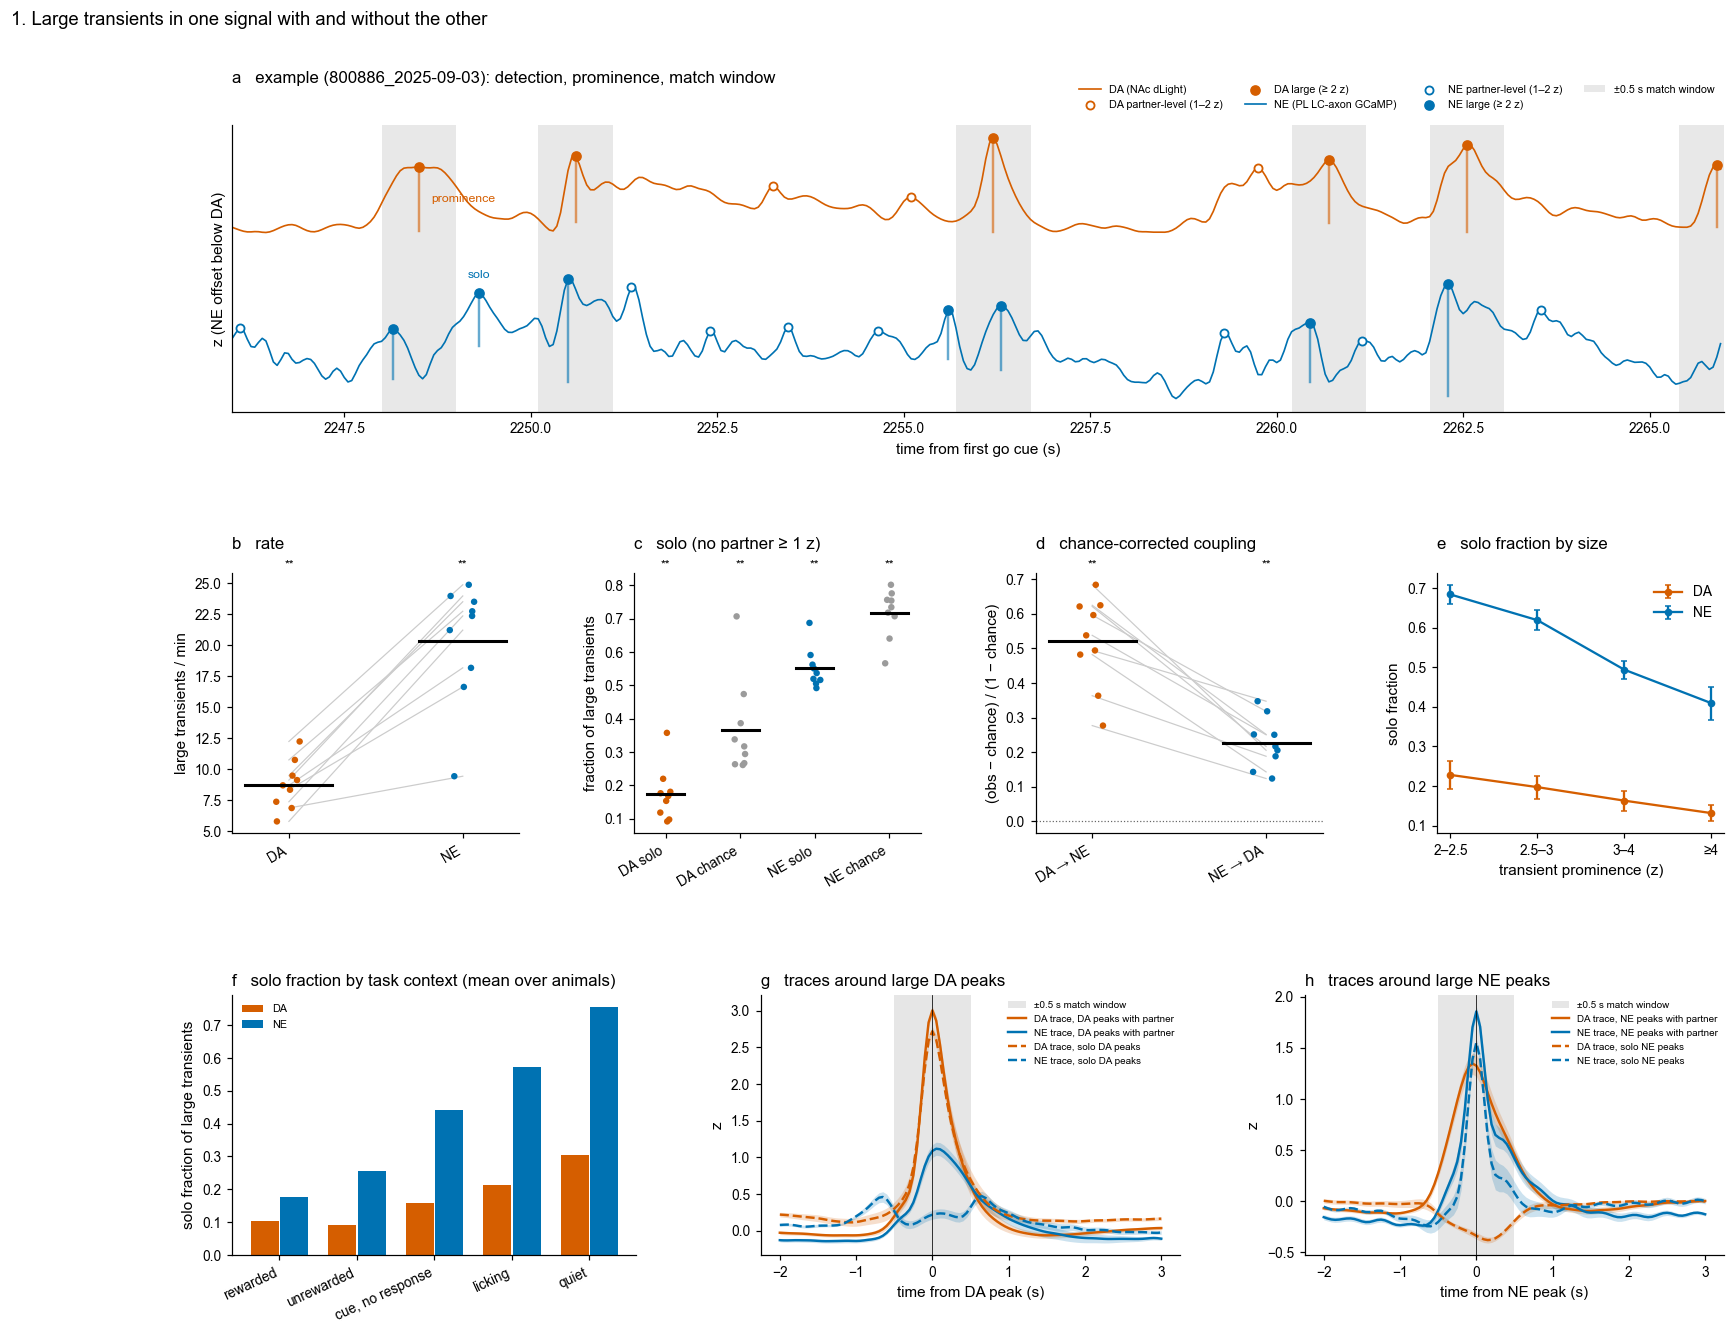

In [7]:
fig = plt.figure(figsize=(17.5, 13))
gs = GridSpec(3, 4, figure=fig, hspace=0.6, wspace=0.4, top=0.9, height_ratios=[1.1, 1, 1])
row3 = gs[2, :].subgridspec(1, 3, width_ratios=[1.3, 1.35, 1.35], wspace=0.3)

ax = fig.add_subplot(gs[0, :])
plot_schematic(ax, ex, snip)
ax.set_title(f"a   example ({ex['session']}): detection, prominence, match window", loc="left",
             pad=28)

ax = fig.add_subplot(gs[1, 0])
pu.strip_by_measure(ax, solo_animal, ["rate_per_min_da", "rate_per_min_ne"], ["DA", "NE"],
             [SIG_COLOR["da"], SIG_COLOR["ne"]], "large transients / min", title="b   rate",
             zero=False)
ax = fig.add_subplot(gs[1, 1])
pu.strip_by_measure(ax, solo_animal, ["solo_frac_da", "chance_solo_da", "solo_frac_ne", "chance_solo_ne"],
             ["DA solo", "DA chance", "NE solo", "NE chance"],
             [SIG_COLOR["da"], NULL_COLOR, SIG_COLOR["ne"], NULL_COLOR],
             "fraction of large transients", title=f"c   solo (no partner ≥ {PARTNER_PROM:g} z)",
             zero=False, connect=False)
ax = fig.add_subplot(gs[1, 2])
pu.strip_by_measure(ax, solo_animal, ["coupling_da", "coupling_ne"], ["DA → NE", "NE → DA"],
             [SIG_COLOR["da"], SIG_COLOR["ne"]], "(obs − chance) / (1 − chance)",
             title="d   chance-corrected coupling")
ax = fig.add_subplot(gs[1, 3])
x = np.arange(len(PROM_BINS) - 1)
for s in ("da", "ne"):
    c = size_curve.xs(s, level="sig")
    ax.errorbar(x, *st.mean_sem(c)[:2], color=SIG_COLOR[s],
                marker="o", ms=4, capsize=2, label=s.upper())
ax.set_xticks(x)
ax.set_xticklabels(["2–2.5", "2.5–3", "3–4", "≥4"])
ax.set_xlabel("transient prominence (z)")
ax.set_ylabel("solo fraction")
ax.set_title("e   solo fraction by size", loc="left", pad=16)
ax.legend()
style_ax(ax)

ax = fig.add_subplot(row3[0])
xx = np.arange(len(CONTEXTS))
for k, s in enumerate(("da", "ne")):
    ax.bar(xx + (k - 0.5) * 0.38, solo_by_ctx.loc[s], width=0.36, color=SIG_COLOR[s],
           label=f"{s.upper()}")
ax.set_xticks(xx)
ax.set_xticklabels(CONTEXTS, rotation=25, ha="right")
ax.set_ylabel("solo fraction of large transients")
ax.set_title("f   solo fraction by task context (mean over animals)", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

for k, (s, title) in enumerate((("da", "g   traces around large DA peaks"),
                                ("ne", "h   traces around large NE peaks"))):
    ax = fig.add_subplot(row3[1 + k])
    ax.axvspan(-MATCH_WIN_S, MATCH_WIN_S, color="0.9", lw=0, zorder=0,
               label=f"±{MATCH_WIN_S:g} s match window")
    for solo, ls in ((False, "-"), (True, "--")):
        for o in ("da", "ne"):
            if (s, solo, o) in eta:
                which = f"solo {s.upper()} peaks" if solo else f"{s.upper()} peaks with partner"
                pu.plot_mean_sem(ax, ETA_LAGS, eta[(s, solo, o)], SIG_COLOR[o],
                            f"{o.upper()} trace, {which}", ls=ls)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel(f"time from {s.upper()} peak (s)")
    ax.set_ylabel("z")
    ax.set_title(title, loc="left")
    ax.legend(fontsize=6.5, loc="upper right", frameon=False, handlelength=1.8,
              borderaxespad=0.2)
    style_ax(ax)

fig.suptitle("1. Large transients in one signal with and without the other", x=0.01,
             ha="left")
save_fig(fig, "fip_11_1_transients", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 2. Detection threshold

Rate and solo fraction of large transients at four prominence thresholds (partner threshold fixed at
1 z, or the large threshold when that is lower), mean ± SEM over animals.

In [8]:
sweep = []
for thr in PROM_SWEEP:
    for p in pairs:
        det = {s: su.detect_transients(p["z"][s], FS, prominence=min(thr, PARTNER_PROM))
               for s in ("da", "ne")}
        for s, o in (("da", "ne"), ("ne", "da")):
            big = det[s][det[s]["prominence"] >= thr]
            _, lag = su.nearest_partner(big["i"].to_numpy() / FS, det[o]["i"].to_numpy() / FS)
            sweep.append(dict(thr=thr, subject=p["subject"], session=p["session"], sig=s,
                              solo=np.mean(np.abs(lag) > MATCH_WIN_S) if len(big) else np.nan,
                              rate=len(big) / (len(p["da"]) / FS) * 60))
sweep = (pd.DataFrame(sweep).groupby(["thr", "subject", "sig"])[["solo", "rate"]].mean()
         .groupby(level=["thr", "sig"]).agg(["mean", "sem"]))
sweep.round(3)

solo           rate       
          mean    sem    mean    sem
thr sig                             
1.5 da   0.197  0.029  11.850  0.972
    ne   0.605  0.020  29.469  2.525
2.0 da   0.174  0.027   8.722  0.659
    ne   0.551  0.020  20.315  1.633
2.5 da   0.157  0.024   6.612  0.532
    ne   0.495  0.023  13.992  1.112
3.0 da   0.145  0.022   5.063  0.450
    ne   0.447  0.029   9.592  0.830

## 3. Matched pairs: lag and size

- **Lag.** For each large DA transient, the nearest NE transient (≥ 1 z), as a histogram of NE peak −
  DA peak per animal, against the NE train circularly shifted once per session. The centre of the
  above-chance pairs is the centre of mass of the positive excess within ±0.5 s.
- **Size.** For matched pairs (large DA transient with an NE partner), the Spearman correlation of
  the two prominences within each task context (contexts with ≥ 20 pairs per animal).

In [9]:
# Lag histograms (NE peak − DA peak), per animal, for large DA transients; null from a circular
# shift of the NE train, drawn once per session.
lag_hist, lag_null = [], []
for subj in SUBJECTS:
    h_obs, h_null = [], []
    for p in (p for p in pairs if p["subject"] == subj):
        g = paired[(paired.session == p["session"]) & (paired.sig == "da")]
        h_obs.append(np.histogram(g["lag"], LAG_BINS)[0] / max(len(g), 1))
        ne_t = transients[(transients.session == p["session"]) & (transients.sig == "ne")]["t"].to_numpy()
        dur = len(p["da"]) / FS
        shifted = su.shift_times(ne_t, (p["t0"], p["t0"] + dur), rng.uniform(30, dur - 30))
        _, l0 = su.nearest_partner(g["t"].to_numpy(), shifted)
        h_null.append(np.histogram(l0, LAG_BINS)[0] / max(len(g), 1))
    lag_hist.append(np.mean(h_obs, 0))
    lag_null.append(np.mean(h_null, 0))
lag_hist, lag_null = np.array(lag_hist), np.array(lag_null)
centers = LAG_BINS[:-1] + 0.05
excess = lag_hist - lag_null
# Centre of mass of the positive excess within the match window: where the above-chance pairs sit.
in_win = np.abs(centers) <= MATCH_WIN_S
pos = np.clip(excess[:, in_win], 0, None)
peak_lag_animal = pd.Series((pos * centers[in_win]).sum(1) / pos.sum(1), index=SUBJECTS)
m, p, n = st.wilcoxon_animals(peak_lag_animal)
print(f"centre of the excess coincidences (NE − DA): per-animal mean {m:+.3f} s, Wilcoxon p = {p:.4f}")
print("excess matched fraction within the window (observed − shifted):",
      pd.Series(excess[:, in_win].sum(1), index=SUBJECTS).round(3).to_dict())

# Amplitude coupling of matched pairs, within context.
mp = paired[(paired.sig == "da") & paired.matched]
amp_rows = []
for (subj, ctx), g in mp.groupby(["subject", "context"]):
    if len(g) >= 20:
        amp_rows.append(dict(subject=subj, context=ctx, n=len(g),
                             rho=stats.spearmanr(g["prominence"], g["partner_prom"])[0]))
amp = pd.DataFrame(amp_rows).pivot(index="subject", columns="context", values="rho")
amp = amp[[c for c in CONTEXTS if c in amp]]
for c in amp:
    m, p, n = st.wilcoxon_animals(amp[c])
    print(f"amplitude rho, {c:17s}: mean {m:+.3f}, p = {p:.4f}, n = {n}")

centre of the excess coincidences (NE − DA): per-animal mean +0.088 s, Wilcoxon p = 0.0039
excess matched fraction within the window (observed − shifted): {'800886': 0.191, '808054': 0.237, '809487': 0.153, '809491': 0.177, '815334': 0.137, '816212': 0.065, '816214': 0.326, '818585': 0.069, '818586': 0.21}
amplitude rho, rewarded         : mean +0.106, p = 0.0039, n = 9
amplitude rho, unrewarded       : mean +0.058, p = 0.0977, n = 9
amplitude rho, cue, no response : mean -0.003, p = 1.0000, n = 8
amplitude rho, licking          : mean +0.065, p = 0.0977, n = 9
amplitude rho, quiet            : mean +0.130, p = 0.0039, n = 9


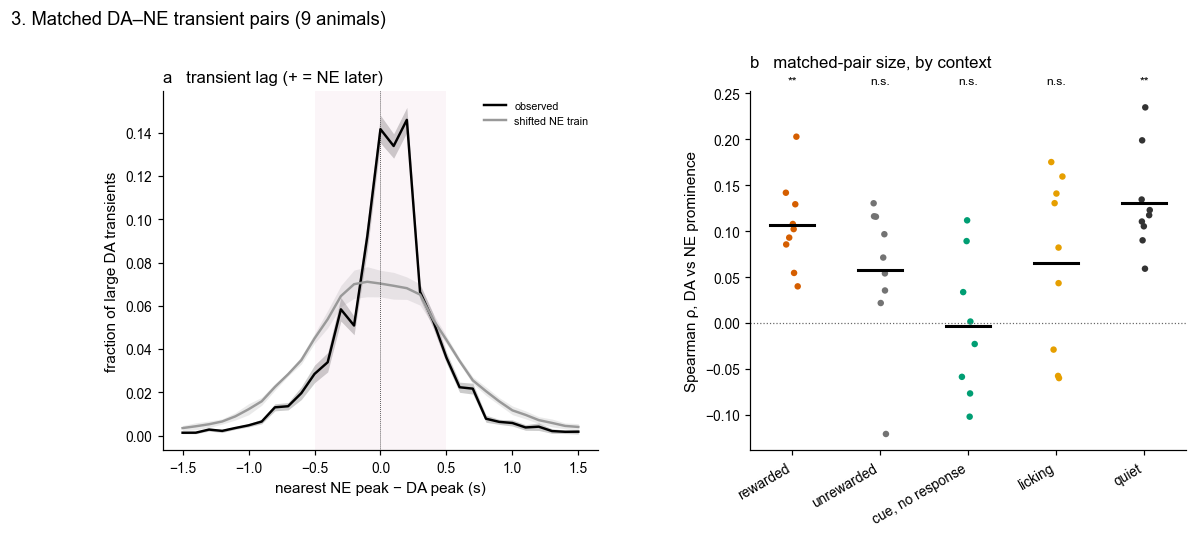

In [10]:
fig = plt.figure(figsize=(12, 4.6))
gs = GridSpec(1, 2, figure=fig, wspace=0.35, top=0.82)
ax = fig.add_subplot(gs[0])
for arr, col, lab in ((lag_hist, "k", "observed"), (lag_null, "0.6", "shifted NE train")):
    pu.plot_mean_sem(ax, centers, arr, col, lab)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.axvspan(-MATCH_WIN_S, MATCH_WIN_S, color=PALETTE["accent"], alpha=0.07, lw=0)
ax.set_xlabel("nearest NE peak − DA peak (s)")
ax.set_ylabel("fraction of large DA transients")
ax.set_title("a   transient lag (+ = NE later)", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[1])
pu.strip_by_measure(ax, amp, list(amp.columns), list(amp.columns),
                    [PALETTE["pos"], "0.45", OKABE_ITO["bluish_green"], OKABE_ITO["orange"], "0.2"][:len(amp.columns)],
                    "Spearman ρ, DA vs NE prominence", title="b   matched-pair size, by context",
                    connect=False)
fig.suptitle(f"3. Matched DA–NE transient pairs ({N_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_11_3_matched_pairs", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 4. Movement around large transients

Large transients and partners as in section 1 (`fu.large_transients`: prominence ≥ 2 z;
partner = a peak ≥ 1 z in the other signal within ±0.5 s). ME is averaged around each group's
peaks, and its mean over −0.5 to +0.5 s compared between solo and partnered transients. Sessions with a usable bottom camera only.

── ME around large transients (z, −0.5 to +0.5 s)
           measure   mean    sem       p  n
        DA with NE  0.723 0.0611 0.00391  9
           DA solo  0.301 0.0469 0.00781  9
        NE with DA  0.697 0.0622 0.00391  9
           NE solo   0.31 0.0928 0.00391  9
DA: solo − with NE -0.422 0.0524 0.00391  9
NE: solo − with DA -0.387  0.066 0.00391  9



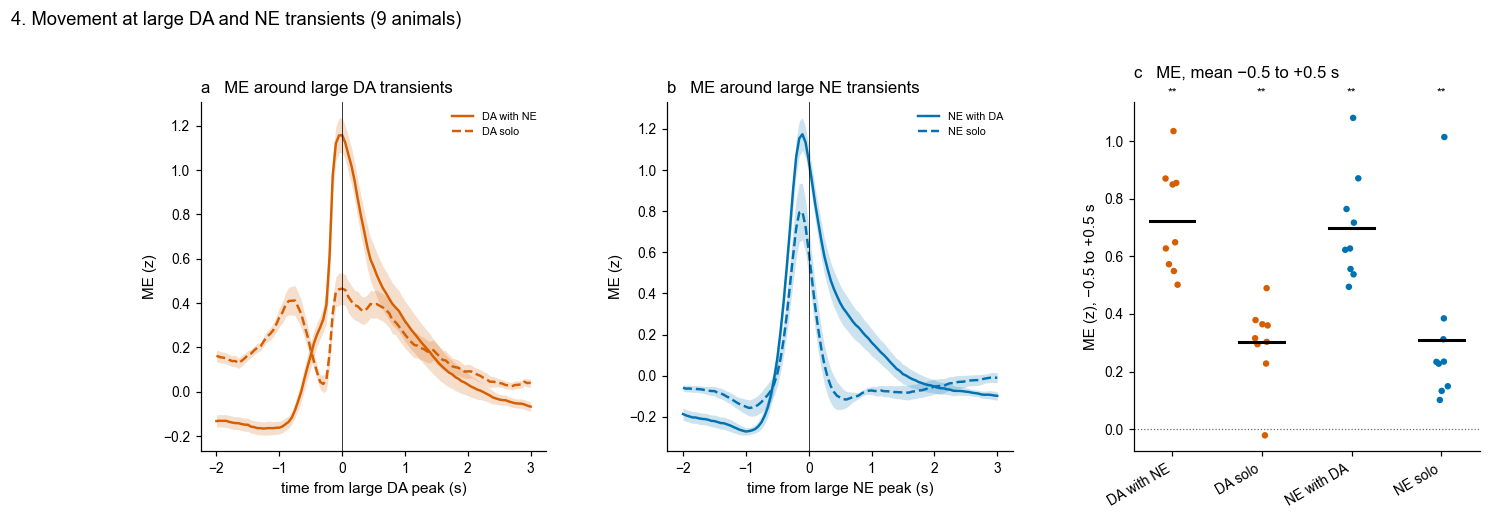

In [11]:
GROUPS = [("da", True), ("da", False), ("ne", True), ("ne", False)]
GROUP_LABEL = {("da", True): "DA with NE", ("da", False): "DA solo",
               ("ne", True): "NE with DA", ("ne", False): "NE solo"}
eta_tr = {g: [] for g in GROUPS}
rows = []
for p in me_pairs:
    z = p["z"]
    r = dict(subject=p["subject"], session=p["session"])
    for s, o in (("da", "ne"), ("ne", "da")):
        big = fu.large_transients(z[s], z[o], p["t0"], FS, LARGE_PROM, PARTNER_PROM, MATCH_WIN_S, MIN_SEP_S)
        for partner in (True, False):
            t = big.loc[big["partner"] == partner, "t"].to_numpy()
            if len(t) < 3:
                continue
            eta_tr[(s, partner)].append((p["subject"], np.nanmean(su.peri_event_grid(z["me"], p["t0"], FS, t, ETA_LAGS), 0)))
            r[GROUP_LABEL[(s, partner)]] = np.nanmean(su.window_mean_grid(z["me"], p["t0"], FS, t, *PEAK_WIN))
    rows.append(r)
tr_sess = pd.DataFrame(rows)
tr_animal = st.animal_means(tr_sess, [GROUP_LABEL[g] for g in GROUPS], by_session=False)
tr_animal["DA: solo − with NE"] = tr_animal["DA solo"] - tr_animal["DA with NE"]
tr_animal["NE: solo − with DA"] = tr_animal["NE solo"] - tr_animal["NE with DA"]
report("ME around large transients (z, −0.5 to +0.5 s)", tr_animal, list(tr_animal))

fig = plt.figure(figsize=(15, 4.6))
gs = GridSpec(1, 3, figure=fig, wspace=0.35, top=0.8)
for j, s in enumerate(("da", "ne")):
    ax = fig.add_subplot(gs[j])
    for partner, ls in ((True, "-"), (False, "--")):
        pu.plot_mean_sem(ax, ETA_LAGS, animal_traces(eta_tr[(s, partner)]), SIG_COLOR[s],
                         GROUP_LABEL[(s, partner)], ls=ls)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel(f"time from large {s.upper()} peak (s)")
    ax.set_ylabel("ME (z)")
    ax.set_title(f"{'ab'[j]}   ME around large {s.upper()} transients", loc="left")
    ax.legend(fontsize=7)
    style_ax(ax)
ax = fig.add_subplot(gs[2])
pu.strip_by_measure(ax, tr_animal, [GROUP_LABEL[g] for g in GROUPS], [GROUP_LABEL[g] for g in GROUPS],
                    [SIG_COLOR["da"], SIG_COLOR["da"], SIG_COLOR["ne"], SIG_COLOR["ne"]],
                    "ME (z), −0.5 to +0.5 s", title="c   ME, mean −0.5 to +0.5 s", connect=False)
fig.suptitle(f"4. Movement at large DA and NE transients ({N_ME_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_11_4_transients", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

### 4, peak ME

The window mean in panel c weighs a tall, narrow ME peak and a low, broad elevation alike. Here,
per animal, the maximum of that animal's average ME trace within ±0.5 s of the transient peak (the
traces of panels a–b), and when it occurs. The maximum is taken from the animal's average trace,
not from single events, so noise in single events does not inflate it.

── peak ME within ±0.5 s (z)
   measure  mean    sem       p  n
DA with NE  1.18 0.0739 0.00391  9
   DA solo 0.519 0.0523 0.00391  9
NE with DA  1.19 0.0824 0.00391  9
   NE solo 0.811  0.141 0.00391  9

── time of peak ME (s from transient peak)
   measure    mean     sem       p  n
DA with NE -0.0222  0.0222   0.652  9
   DA solo -0.0444  0.0679   0.652  9
NE with DA    -0.1  0.0118 0.00391  9
   NE solo  -0.122 0.00878 0.00391  9

── peak ME, group against group (Wilcoxon on animal differences)
             comparison  mean_diff       p animals_positive
      NE solo − DA solo      0.292  0.0742              7/9
NE with DA − DA with NE    0.00845    0.91              4/9
   DA solo − DA with NE      -0.66 0.00391              0/9
   NE solo − NE with DA     -0.377  0.0117              1/9


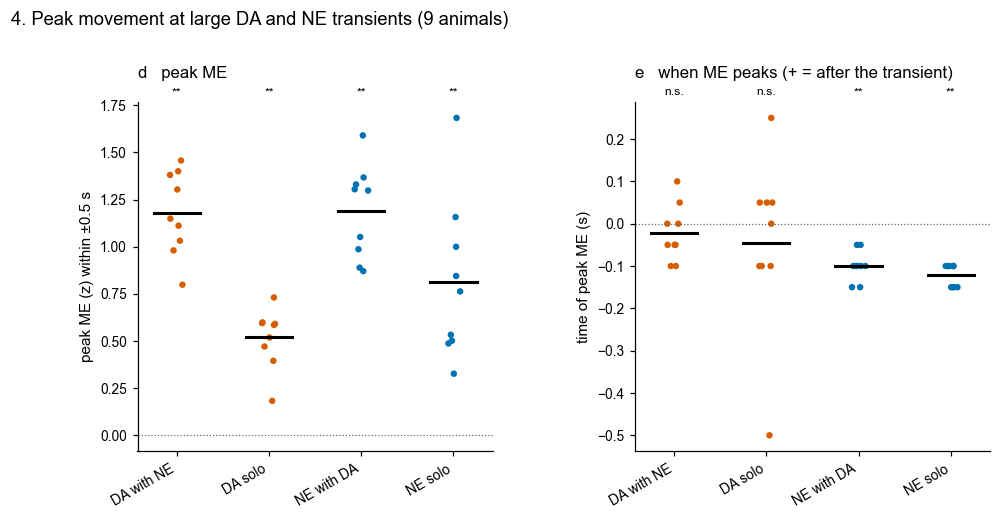

In [12]:
in_win = (ETA_LAGS >= PEAK_WIN[0]) & (ETA_LAGS <= PEAK_WIN[1])
peak_rows = []
for g in GROUPS:
    subj, traces = zip(*eta_tr[g])
    labels, avg = st.group_means(traces, subj)
    for a, tr in zip(labels, avg):
        k = int(np.nanargmax(tr[in_win]))
        peak_rows.append(dict(subject=a, group=GROUP_LABEL[g], peak=tr[in_win][k],
                              peak_time=ETA_LAGS[in_win][k]))
peak_long = pd.DataFrame(peak_rows)
peak_animal = peak_long.pivot(index="subject", columns="group", values="peak")[[GROUP_LABEL[g] for g in GROUPS]]
time_animal = peak_long.pivot(index="subject", columns="group", values="peak_time")[[GROUP_LABEL[g] for g in GROUPS]]
report("peak ME within ±0.5 s (z)", peak_animal, list(peak_animal))
report("time of peak ME (s from transient peak)", time_animal, list(time_animal))

cmp_rows = []
for x, y in (("NE solo", "DA solo"), ("NE with DA", "DA with NE"), ("DA solo", "DA with NE"),
             ("NE solo", "NE with DA")):
    d = peak_animal[x] - peak_animal[y]
    mean, pv, n = st.wilcoxon_animals(d)
    cmp_rows.append(dict(comparison=f"{x} − {y}", mean_diff=mean, p=pv,
                         animals_positive=f"{int((d > 0).sum())}/{n}"))
peak_cmp = pd.DataFrame(cmp_rows)
print("── peak ME, group against group (Wilcoxon on animal differences)")
print(peak_cmp.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

fig = plt.figure(figsize=(10, 4.6))
gs = GridSpec(1, 2, figure=fig, wspace=0.4, top=0.8)
cols = [GROUP_LABEL[g] for g in GROUPS]
colors = [SIG_COLOR["da"], SIG_COLOR["da"], SIG_COLOR["ne"], SIG_COLOR["ne"]]
ax = fig.add_subplot(gs[0])
pu.strip_by_measure(ax, peak_animal, cols, cols, colors, "peak ME (z) within ±0.5 s",
                    title="d   peak ME", connect=False)
ax = fig.add_subplot(gs[1])
pu.strip_by_measure(ax, time_animal, cols, cols, colors, "time of peak ME (s)",
                    title="e   when ME peaks (+ = after the transient)", connect=False)
fig.suptitle(f"4. Peak movement at large DA and NE transients ({N_ME_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_11_4_transients_peak", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 5. Numbers

One row per measure: mean of animal means, Wilcoxon p against zero, animals positive.

In [13]:
def row(section, measure, df, col):
    # one measure of an animal table: mean, Wilcoxon p against 0, animals positive
    v = df[col]
    m, p, n = st.wilcoxon_animals(v)
    return dict(section=section, measure=measure, mean=round(m, 3), p=round(p, 4),
                animals_positive=f"{int((v > 0).sum())}/{n}")


def from_sessions(df, col):
    return df.groupby("subject")[col].mean().to_frame(col)


da_s, ne_s = solo_sess[solo_sess.sig == "da"], solo_sess[solo_sess.sig == "ne"]
S = [row("1", "large DA transients / min", from_sessions(da_s, "rate_per_min"), "rate_per_min"),
     row("1", "large NE transients / min", from_sessions(ne_s, "rate_per_min"), "rate_per_min"),
     row("1", "DA solo fraction", from_sessions(da_s, "solo_frac"), "solo_frac"),
     row("1", "NE solo fraction", from_sessions(ne_s, "solo_frac"), "solo_frac"),
     row("1", "DA → NE chance-corrected coupling", from_sessions(da_s, "coupling"), "coupling"),
     row("1", "NE → DA chance-corrected coupling", from_sessions(ne_s, "coupling"), "coupling"),
     row("3", "transient lag, centre of excess (s, + = NE later)", peak_lag_animal.to_frame("lag"), "lag")]
S += [row("3", f"matched-pair size ρ, {c}", amp, c) for c in amp.columns]
S += [row("4", f"ME −0.5 to +0.5 s, {c}", tr_animal, c) for c in tr_animal]
S += [row("4", f"peak ME, {c}", peak_animal, c) for c in peak_animal]
pd.DataFrame(S).set_index(["section", "measure"])

mean       p animals_positive
section measure                                                                           
1       large DA transients / min                           8.722  0.0039              9/9
        large NE transients / min                          20.315  0.0039              9/9
        DA solo fraction                                    0.174  0.0039              9/9
        NE solo fraction                                    0.551  0.0039              9/9
        DA → NE chance-corrected coupling                   0.520  0.0039              9/9
        NE → DA chance-corrected coupling                   0.227  0.0039              9/9
3       transient lag, centre of excess (s, + = NE later)   0.088  0.0039              9/9
        matched-pair size ρ, rewarded                       0.106  0.0039              9/9
        matched-pair size ρ, unrewarded                     0.058  0.0977              8/9
        matched-pair size ρ, cue, no response              -0.003  1.0000              4/8
        matched-pair size ρ, licking                        0.065  0.0977              6/9
        matched-pair size ρ, quiet                          0.130  0.0039              9/9
4       ME −0.5 to +0.5 s, DA with NE                       0.723  0.0039              9/9
        ME −0.5 to +0.5 s, DA solo                          0.301  0.0078              8/9
        ME −0.5 to +0.5 s, NE with DA                       0.697  0.0039              9/9
        ME −0.5 to +0.5 s, NE solo                          0.310  0.0039              9/9
        ME −0.5 to +0.5 s, DA: solo − with NE              -0.422  0.0039              0/9
        ME −0.5 to +0.5 s, NE: solo − with DA              -0.387  0.0039              0/9
        peak ME, DA with NE                                 1.179  0.0039              9/9
        peak ME, DA solo                                    0.519  0.0039              9/9
        peak ME, NE with DA                                 1.188  0.0039              9/9
        peak ME, NE solo                                    0.811  0.0039              9/9